
# Лабораторная работа №1
## Необходимые и достаточные условия существования условного экстремума

### Цель работы

1. Исследовать необходимые и достаточные условия существования экстремума функции с учетом ограничений.
2. Найти стационарные точки задачи условной оптимизации.
3. Проверить условия допустимости, условия первого порядка и условия второго порядка.
4. Представить результат аналитически, программно и графически.


Требуется найти условный минимум функции

$$
 f(x)=3x_1^2+4x_1x_2+5x_2^2 \to \min
$$

при ограничениях

$$
\begin{cases}
 g_1(x)=4-x_1-x_2 \le 0,\\
 g_2(x)=-x_1 \le 0,\\
 g_3(x)=-x_2 \le 0.
\end{cases}
$$

То есть множество допустимых решений имеет вид

$$
X=\{(x_1,x_2): x_1+x_2\ge 4,\; x_1\ge 0,\; x_2\ge 0\}.
$$

Так как матрица Гессе целевой функции положительно определена, задача является выпуклой, поэтому найденная точка KKT будет не только локальным, но и глобальным минимумом.


In [2]:
!pip install sympy

  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)

   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   -------------------- ------------------- 1/2 [sympy]
   -------------------- ------

In [3]:

import itertools
import math

import numpy as np
import pandas as pd
import sympy as sp
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

sp.init_printing(use_latex='mathjax')



## Объявление функций и ограничений


In [4]:

x1, x2 = sp.symbols('x_1 x_2', real=True)
mu1, mu2, mu3 = sp.symbols('mu_1 mu_2 mu_3', real=True)

x = sp.Matrix([x1, x2])

f = 3*x1**2 + 4*x1*x2 + 5*x2**2
constraints = [4 - x1 - x2, -x1, -x2]
constraint_names = ['g1 = 4 - x1 - x2', 'g2 = -x1', 'g3 = -x2']
mu = [mu1, mu2, mu3]

L = f + sum(mu_i * g_i for mu_i, g_i in zip(mu, constraints))
grad_f = sp.Matrix([sp.diff(f, v) for v in (x1, x2)])
grad_g = [sp.Matrix([sp.diff(g, v) for v in (x1, x2)]) for g in constraints]
H_f = sp.hessian(f, (x1, x2))
H_L = sp.hessian(L, (x1, x2))

display(Markdown('### Целевая функция'))
display(f)

display(Markdown('### Ограничения'))
for name, g in zip(constraint_names, constraints):
    display(Markdown(f'**{name}:**'))
    display(g)

display(Markdown('### Градиент целевой функции'))
display(grad_f)

display(Markdown('### Матрица Гессе целевой функции'))
display(H_f)

display(Markdown('### Собственные значения матрицы Гессе'))
display(H_f.eigenvals())


### Целевая функция

    2                 2
3⋅x₁  + 4⋅x₁⋅x₂ + 5⋅x₂ 

### Ограничения

**g1 = 4 - x1 - x2:**

-x₁ - x₂ + 4

...

⎡6⋅x₁ + 4⋅x₂ ⎤
⎢            ⎥
⎣4⋅x₁ + 10⋅x₂⎦

### Матрица Гессе целевой функции

⎡6  4 ⎤
⎢     ⎥
⎣4  10⎦

### Собственные значения матрицы Гессе

{8 - 2⋅√5: 1, 2⋅√5 + 8: 1}


Матрица Гессе

$$
H_f=\begin{pmatrix}6&4\\4&10\end{pmatrix}
$$

имеет положительные главные миноры:

$$
6>0,\qquad \det H_f=6\cdot 10-4\cdot 4=44>0.
$$

Следовательно, функция строго выпукла.



## Необходимые условия первого порядка

Составим классическую функцию Лагранжа для задачи минимизации с ограничениями $g_i(x)\le0$:

$$
L(x,\mu)=f(x)+\mu_1g_1(x)+\mu_2g_2(x)+\mu_3g_3(x),\qquad \mu_i\ge0.
$$

Условия KKT:

$$
\begin{cases}
\nabla_xL(x,\mu)=0,\\
g_i(x)\le0,\\
\mu_i\ge0,\\
\mu_i g_i(x)=0,\quad i=1,2,3.
\end{cases}
$$

Для данной задачи:

$$
\begin{cases}
6x_1+4x_2-\mu_1-\mu_2=0,\\
4x_1+10x_2-\mu_1-\mu_3=0,\\
4-x_1-x_2\le0,\\
-x_1\le0,\\
-x_2\le0,\\
\mu_i\ge0,\\
\mu_i g_i(x)=0.
\end{cases}
$$



## Проверка случая $\lambda_0=0$ в обобщенной функции Лагранжа

В обобщенной функции Лагранжа

$$
L_0(x,\lambda_0,\lambda)=\lambda_0 f(x)+\sum_{i=1}^3\lambda_i g_i(x)
$$

при $\lambda_0=0$ условия стационарности принимают вид:

$$
-\lambda_1-\lambda_2=0,\qquad -\lambda_1-\lambda_3=0.
$$

Для минимума требуется $\lambda_i\ge0$. Отсюда следует $\lambda_1=\lambda_2=\lambda_3=0$, что запрещено условием нетривиальности множителей. Следовательно, нерегулярных стационарных точек при $\lambda_0=0$ нет, и далее можно рассматривать нормальный случай $\lambda_0\ne0$, полагая $\lambda_0=1$.



## Поиск стационарных точек перебором активных ограничений

Ограничение считается активным, если $g_i(x)=0$. Для каждого возможного набора активных ограничений решается система:

$$
\nabla f(x)+\sum_{i\in A}\mu_i\nabla g_i(x)=0,\qquad g_i(x)=0,\; i\in A.
$$

После решения проверяются:

1. допустимость точки;
2. неотрицательность множителей Лагранжа для активных ограничений;
3. выполнение условия дополняющей нежесткости.


In [5]:

def as_float(value):
    return float(sp.N(value))

rows = []
valid_kkt_points = []

indices = range(len(constraints))

for r in range(len(constraints) + 1):
    for active in itertools.combinations(indices, r):
        active = tuple(active)
        active_mu_symbols = [mu[i] for i in active]
        equations = []
        stationarity = grad_f.copy()
        for i in active:
            stationarity += mu[i] * grad_g[i]
        equations.extend(list(stationarity))
        equations.extend([constraints[i] for i in active])

        unknowns = [x1, x2] + active_mu_symbols
        solutions = sp.solve(equations, unknowns, dict=True)

        if not solutions:
            rows.append({
                'Активные ограничения': ', '.join([f'g{i+1}' for i in active]) or 'нет',
                'x1': '—',
                'x2': '—',
                'mu активных': '—',
                'g(x)': '—',
                'Допустима': 'нет решения',
                'mu >= 0': '—',
                'KKT для min': 'нет',
                'f(x)': '—'
            })
            continue

        for sol in solutions:
            x_val = sp.Matrix([sp.simplify(sol[x1]), sp.simplify(sol[x2])])
            g_vals = [sp.simplify(g.subs({x1: x_val[0], x2: x_val[1]})) for g in constraints]
            mu_vals = [sp.Integer(0)] * len(constraints)
            for i in active:
                mu_vals[i] = sp.simplify(sol[mu[i]])

            feasible = all(as_float(gv) <= 1e-9 for gv in g_vals)
            nonnegative_mu = all(as_float(mu_vals[i]) >= -1e-9 for i in active)
            complementary = all(abs(as_float(mu_vals[i] * g_vals[i])) <= 1e-9 for i in indices)
            is_kkt = feasible and nonnegative_mu and complementary
            f_val = sp.simplify(f.subs({x1: x_val[0], x2: x_val[1]}))

            rows.append({
                'Активные ограничения': ', '.join([f'g{i+1}' for i in active]) or 'нет',
                'x1': x_val[0],
                'x2': x_val[1],
                'mu активных': ', '.join([f'μ{i+1}={mu_vals[i]}' for i in active]) or '—',
                'g(x)': tuple(g_vals),
                'Допустима': 'да' if feasible else 'нет',
                'mu >= 0': 'да' if nonnegative_mu else 'нет',
                'KKT для min': 'да' if is_kkt else 'нет',
                'f(x)': f_val,
            })
            if is_kkt:
                valid_kkt_points.append((x_val, mu_vals, f_val, active))

candidates_df = pd.DataFrame(rows)
display(candidates_df)


,Активные ограничения,x1,x2,mu активных,g(x),Допустима,mu >= 0,KKT для min,f(x)
0,нет,0,0,—,"(4, 0, 0)",нет,да,нет,0
1,g1,3,1,μ1=22,"(0, -3, -1)",да,да,да,44
2,g2,0,0,μ2=0,"(4, 0, 0)",нет,да,нет,0
3,g3,0,0,μ3=0,"(4, 0, 0)",нет,да,нет,0
4,"g1, g2",0,4,"μ1=40, μ2=-24","(0, 0, -4)",да,нет,нет,80
5,"g1, g3",4,0,"μ1=24, μ3=-8","(0, -4, 0)",да,нет,нет,48
6,"g2, g3",0,0,"μ2=0, μ3=0","(4, 0, 0)",нет,да,нет,0
7,"g1, g2, g3",—,—,—,—,нет решения,—,нет,—



Из перебора активных ограничений следует, что единственная точка, удовлетворяющая условиям KKT для задачи минимизации:

$$
 x^*=(3,1),\qquad \mu^*=(22,0,0).
$$


In [6]:

x_star, mu_star, f_star, active_star = valid_kkt_points[0]
subs_star = {x1: x_star[0], x2: x_star[1], mu1: mu_star[0], mu2: mu_star[1], mu3: mu_star[2]}

result_df = pd.DataFrame([
    {
        'x*': f'({x_star[0]}, {x_star[1]})',
        'mu*': f'({mu_star[0]}, {mu_star[1]}, {mu_star[2]})',
        'f(x*)': f_star,
        'g1(x*)': constraints[0].subs(subs_star),
        'g2(x*)': constraints[1].subs(subs_star),
        'g3(x*)': constraints[2].subs(subs_star),
        'Активные ограничения': ', '.join([f'g{i+1}' for i in active_star]),
    }
])

display(result_df)


,x*,mu*,f(x*),g1(x*),g2(x*),g3(x*),Активные ограничения
0,"(3, 1)","(22, 0, 0)",44,0,-3,-1,g1



## Проверка допустимости решения

Для точки $x^*=(3,1)$:

$$
\begin{aligned}
g_1(x^*)&=4-3-1=0,\\
g_2(x^*)&=-3<0,\\
g_3(x^*)&=-1<0.
\end{aligned}
$$

Следовательно, точка допустима. Ограничение $g_1$ активно, ограничения $g_2$ и $g_3$ пассивны.

Значение целевой функции:

$$
f(3,1)=3\cdot 3^2+4\cdot 3\cdot 1+5\cdot 1^2=44.
$$



## Проверка условий первого порядка в найденной точке


In [7]:

display(Markdown('### Градиент функции Лагранжа'))
display(sp.Matrix([sp.diff(L, x1), sp.diff(L, x2)]))

grad_L_at_star = sp.Matrix([sp.diff(L, v).subs(subs_star) for v in (x1, x2)])
complementarity_at_star = [sp.simplify(mu_star[i] * constraints[i].subs({x1: x_star[0], x2: x_star[1]})) for i in indices]

check_df = pd.DataFrame([
    {'Условие': 'Стационарность ∇L(x*, μ*)', 'Значение': tuple(grad_L_at_star), 'Выполнено': grad_L_at_star == sp.Matrix([0, 0])},
    {'Условие': 'Допустимость g(x*) ≤ 0', 'Значение': tuple([g.subs({x1: x_star[0], x2: x_star[1]}) for g in constraints]), 'Выполнено': True},
    {'Условие': 'Неотрицательность μ* ≥ 0', 'Значение': tuple(mu_star), 'Выполнено': all(v >= 0 for v in mu_star)},
    {'Условие': 'Дополняющая нежесткость μᵢgᵢ(x*) = 0', 'Значение': tuple(complementarity_at_star), 'Выполнено': all(v == 0 for v in complementarity_at_star)},
])

display(check_df)


### Градиент функции Лагранжа

⎡-μ₁ - μ₂ + 6⋅x₁ + 4⋅x₂ ⎤
⎢                       ⎥
⎣-μ₁ - μ₃ + 4⋅x₁ + 10⋅x₂⎦

,Условие,Значение,Выполнено
0,"Стационарность ∇L(x*, μ*)","(0, 0)",True
1,Допустимость g(x*) ≤ 0,"(0, -3, -1)",True
2,Неотрицательность μ* ≥ 0,"(22, 0, 0)",True
3,Дополняющая нежесткость μᵢgᵢ(x*) = 0,"(0, 0, 0)",True



## Второй порядок: способ 1 — исследование второго дифференциала на критическом направлении

В точке $x^*=(3,1)$ активно только ограничение

$$
g_1(x)=4-x_1-x_2=0.
$$

Так как $\mu_1^*=22>0$, для критических направлений должно выполняться равенство

$$
dg_1(x^*)=-dx_1-dx_2=0.
$$

Отсюда

$$
dx_2=-dx_1.
$$

Пусть $dx=(t,-t)$, $t\ne0$. Поскольку ограничения линейные, матрица Гессе функции Лагранжа совпадает с матрицей Гессе целевой функции:

$$
\nabla_{xx}^2 L(x^*,\mu^*)=\nabla^2 f=\begin{pmatrix}6&4\\4&10\end{pmatrix}.
$$


In [8]:

t = sp.symbols('t', real=True)
d = sp.Matrix([t, -t])
second_diff = sp.simplify((d.T * H_f * d)[0])

display(Markdown('### Второй дифференциал на критическом направлении'))
display(second_diff)


### Второй дифференциал на критическом направлении

   2
8⋅t 


Получено:

$$
d^2L(x^*,\mu^*)=8t^2>0\quad \text{для любого}\quad t\ne0.
$$

Следовательно, необходимые условия второго порядка выполняются, а достаточные условия второго порядка для строгого локального минимума также выполняются.



## Второй порядок: способ 2 — редуцированная матрица Гессе и окаймленная матрица

Для активного ограничения $g_1$ матрица Якоби активных ограничений:

$$
A=\begin{pmatrix}-1&-1\end{pmatrix}.
$$

Базис нуль-пространства $A$ можно взять как

$$
Z=\begin{pmatrix}1\\-1\end{pmatrix}.
$$

Редуцированная матрица Гессе:

$$
Z^T H_f Z.
$$

Если она положительно определена, достаточные условия минимума выполнены.


In [9]:

A = sp.Matrix([[-1, -1]])
Z = sp.Matrix([[1], [-1]])
reduced_hessian = sp.simplify(Z.T * H_f * Z)

bordered_hessian = sp.Matrix([
    [0, -1, -1],
    [-1, H_f[0, 0], H_f[0, 1]],
    [-1, H_f[1, 0], H_f[1, 1]],
])
bordered_det = sp.det(bordered_hessian)
bordered_criterion = (-1) ** 1 * bordered_det

second_order_df = pd.DataFrame([
    {'Проверка': 'ZᵀHZ', 'Значение': reduced_hessian[0, 0], 'Вывод': 'положительно'},
    {'Проверка': 'det окаймленной матрицы', 'Значение': bordered_det, 'Вывод': 'для m=1: (-1)^m det B > 0'},
    {'Проверка': '(-1)^m det B', 'Значение': bordered_criterion, 'Вывод': 'положительно'},
])

display(Markdown('### Редуцированная матрица Гессе'))
display(reduced_hessian)

display(Markdown('### Окаймленная матрица Гессе'))
display(bordered_hessian)

display(second_order_df)


### Редуцированная матрица Гессе

[8]

### Окаймленная матрица Гессе

⎡0   -1  -1⎤
⎢          ⎥
⎢-1  6   4 ⎥
⎢          ⎥
⎣-1  4   10⎦

,Проверка,Значение,Вывод
0,ZᵀHZ,8,положительно
1,det окаймленной матрицы,-8,для m=1: (-1)^m det B > 0
2,(-1)^m det B,8,положительно



Редуцированная матрица положительна:

$$
Z^TH_fZ=8>0.
$$

Также выполнен критерий через окаймленную матрицу Гессе:

$$
\det B=-8,\qquad (-1)^1\det B=8>0.
$$

Оба способа подтверждают строгий условный минимум в точке $x^*=(3,1)$.



## Проверка отсутствия условного максимума

Хотя в варианте №4 требуется именно минимум, отметим, что условный максимум на множестве $X$ отсутствует, так как функция не ограничена сверху. Например, при $x_1=x_2=t$ и $t\ge2$ все ограничения выполнены, а

$$
f(t,t)=3t^2+4t^2+5t^2=12t^2\to+\infty\quad \text{при}\quad t\to+\infty.
$$


In [10]:

t_positive = sp.symbols('t', positive=True)
f_path = sp.simplify(f.subs({x1: t_positive, x2: t_positive}))
limit_path = sp.limit(f_path, t_positive, sp.oo)

display(Markdown('### Значение функции на допустимом луче x1=x2=t'))
display(f_path)
display(Markdown('### Предел при t → +∞'))
display(limit_path)


### Значение функции на допустимом луче x1=x2=t

    2
12⋅t 

### Предел при t → +∞

∞


## Графическая проверка результата

На графике показаны:

- допустимая область $x_1+x_2\ge4$, $x_1\ge0$, $x_2\ge0$;
- линии уровня целевой функции;
- найденная точка минимума $x^*=(3,1)$.


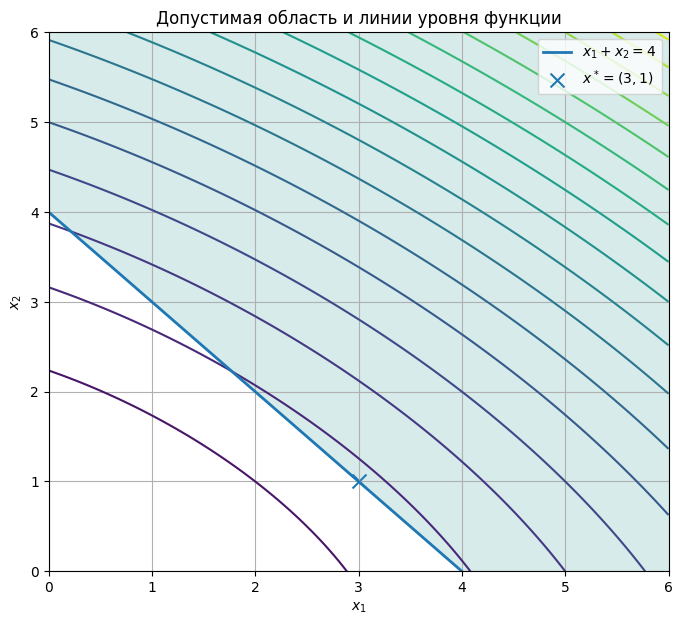

In [11]:

xx = np.linspace(0, 6, 400)
yy = np.linspace(0, 6, 400)
XX, YY = np.meshgrid(xx, yy)
FF = 3*XX**2 + 4*XX*YY + 5*YY**2
feasible_mask = (XX + YY >= 4)

plt.figure(figsize=(8, 7))
plt.contour(XX, YY, FF, levels=18)
plt.contourf(XX, YY, feasible_mask.astype(int), levels=[0.5, 1.5], alpha=0.18)
plt.plot([0, 4], [4, 0], linewidth=2, label=r'$x_1+x_2=4$')
plt.scatter([float(x_star[0])], [float(x_star[1])], s=100, marker='x', label=r'$x^*=(3,1)$')
plt.xlabel(r'$x_1$')
plt.ylabel(r'$x_2$')
plt.title('Допустимая область и линии уровня функции')
plt.xlim(0, 6)
plt.ylim(0, 6)
plt.grid(True)
plt.legend()
plt.show()



## Численная проверка по сетке

Для дополнительной проверки рассчитаем значение функции на сетке допустимых точек. Эта проверка не заменяет аналитические условия KKT, но наглядно подтверждает найденный минимум.


In [12]:

grid = np.linspace(0, 6, 1201)
X1, X2 = np.meshgrid(grid, grid)
F_grid = 3*X1**2 + 4*X1*X2 + 5*X2**2
mask = (X1 + X2 >= 4)
F_masked = np.where(mask, F_grid, np.inf)
min_index = np.unravel_index(np.argmin(F_masked), F_masked.shape)

numerical_x1 = X1[min_index]
numerical_x2 = X2[min_index]
numerical_f = F_masked[min_index]

numerical_check_df = pd.DataFrame([
    {'Метод': 'Аналитически, KKT', 'x1': float(x_star[0]), 'x2': float(x_star[1]), 'f': float(f_star)},
    {'Метод': 'По сетке', 'x1': numerical_x1, 'x2': numerical_x2, 'f': numerical_f},
])

display(numerical_check_df)


,Метод,x1,x2,f
0,"Аналитически, KKT",3.0,1.0,44.0
1,По сетке,3.0,1.0,44.0



## Итоговая таблица


In [13]:

summary_df = pd.DataFrame([
    {
        'Тип точки': 'строгий условный минимум',
        'x1': sp.simplify(x_star[0]),
        'x2': sp.simplify(x_star[1]),
        'f(x)': sp.simplify(f_star),
        'Активные ограничения': 'g1',
        'Пассивные ограничения': 'g2, g3',
        'Множители Лагранжа': f'μ1={mu_star[0]}, μ2={mu_star[1]}, μ3={mu_star[2]}',
        'Допустимость': 'g1=0, g2=-3, g3=-1',
    },
    {
        'Тип точки': 'условный максимум',
        'x1': '—',
        'x2': '—',
        'f(x)': 'не существует',
        'Активные ограничения': '—',
        'Пассивные ограничения': '—',
        'Множители Лагранжа': '—',
        'Допустимость': 'функция не ограничена сверху на X',
    }
])

display(summary_df)


,Тип точки,x1,x2,f(x),Активные ограничения,Пассивные ограничения,Множители Лагранжа,Допустимость
0,строгий условный минимум,3,1,44,g1,"g2, g3","μ1=22, μ2=0, μ3=0","g1=0, g2=-3, g3=-1"
1,условный максимум,—,—,не существует,—,—,—,функция не ограничена сверху на X



## Вывод

Для варианта №4 была исследована задача условной оптимизации

$$
f(x)=3x_1^2+4x_1x_2+5x_2^2\to\min
$$

при ограничениях

$$
4-x_1-x_2\le0,\qquad -x_1\le0,\qquad -x_2\le0.
$$

Найдена единственная стационарная точка, удовлетворяющая условиям KKT:

$$
\boxed{x^*=(3,1)}.
$$

Значение функции в этой точке:

$$
\boxed{f(x^*)=44}.
$$

Проверка допустимости показала:

$$
g_1(x^*)=0,\qquad g_2(x^*)=-3<0,\qquad g_3(x^*)=-1<0.
$$

Множители Лагранжа:

$$
\boxed{\mu^*=(22,0,0)}.
$$

Необходимые условия первого порядка, необходимые условия второго порядка и достаточные условия второго порядка выполнены. Так как целевая функция строго выпукла, а множество допустимых решений выпукло, найденная точка является строгим глобальным минимумом. Условный максимум на данном множестве отсутствует, поскольку функция не ограничена сверху.
